In [49]:
# Import necessary libraries
from google.cloud import bigquery
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier

import matplotlib.pyplot as plt


In [35]:
# Set up BigQuery client
PROJECT_ID = "amex-46887"
DATASET_ID = "amex_risk"

client = bigquery.Client(project=PROJECT_ID, location="US")

In [36]:
# Load model dataset
query = """
SELECT *
FROM `amex-46887.amex_risk.model_dataset_v2`
"""

df = client.query(query).to_dataframe()

print(df.shape)
df.head()

(458913, 66)


,customer_ID,target,n_statements,P_2_avg,P_2_min,P_2_max,P_2_std,P_2_range,D_39_avg,D_39_min,...,D_39_missing_pct,B_9_missing_count,B_9_missing_pct,R_1_missing_count,R_1_missing_pct,B_11_missing_count,B_11_missing_pct,S_3_missing_count,S_3_missing_pct,history_days
0,0ce494a08251a7493cfdab4b4348d903dd88c9908b1287...,0,13,0.899208,0.867373,0.915915,0.014855,0.048542,0.130881,0.000144,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,389
1,138e0604d8e5ad253cd8c049cb3e84fe3b27915889282a...,0,13,0.831651,0.805928,0.867648,0.019745,0.061720,0.007104,0.001337,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,366
2,9189a3926509c9a08a48e3894bf042ec9e55fe6c99a615...,0,13,0.902865,0.864215,0.978155,0.031982,0.113939,0.255876,0.005088,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,373
3,d384a51f830e5bc55ff365715c1cb462dea5670dbba4c0...,1,13,0.438565,0.295611,0.512445,0.071107,0.216834,0.060003,0.001054,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,381
4,ed2e5d27e894398391847ef13752bcb7ba14a674498112...,0,13,0.723871,0.666130,0.802647,0.049746,0.136517,0.282936,0.001385,...,0.0,0,0.0,0,0.0,0,0.0,0,0.0,368


In [37]:
print(df.shape)
display(df["target"].value_counts())
display(df.isnull().sum().sort_values(ascending=False).head(20))

(458913, 66)


target
0    340085
1    118828
Name: count, dtype: Int64

S_3_delta     108758
S_3_first      85940
S_3_latest     84970
S_3_std        63446
S_3_range      56596
S_3_max        56596
S_3_avg        56596
S_3_min        56596
P_2_delta      18022
P_2_first      17498
P_2_std         7829
B_11_std        5120
R_1_std         5120
B_9_std         5120
D_39_std        5120
P_2_latest      2969
P_2_max         2434
P_2_min         2434
P_2_range       2434
P_2_avg         2434
dtype: int64

In [38]:
# Prepare feature matrix
drop_cols = [
    "customer_ID",
    "target",
    "latest_statement_date",
    "first_statement_date"
]

X = df.drop(columns=drop_cols, errors="ignore").copy()
y = df["target"].copy()

numeric_cols = [col for col in X.columns if is_numeric_dtype(X[col])]
X = X[numeric_cols].copy()

X = X.fillna(-999)

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)
print(X.dtypes.value_counts())

Feature matrix shape: (458913, 62)
Target shape: (458913,)
float64    54
Int64       8
Name: count, dtype: int64


In [39]:
# Train/validation split
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_valid.shape)

(367130, 62) (91783, 62)


In [40]:
# Logistic Regression baseline
log_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced",
    solver="liblinear",
    random_state=42
)

log_model.fit(X_train, y_train)

log_preds = log_model.predict(X_valid)
log_probs = log_model.predict_proba(X_valid)[:, 1]

print("Logistic ROC-AUC:", roc_auc_score(y_valid, log_probs))
print("Logistic Accuracy:", accuracy_score(y_valid, log_preds))
print("Logistic Precision:", precision_score(y_valid, log_preds))
print("Logistic Recall:", recall_score(y_valid, log_preds))
print("Logistic F1:", f1_score(y_valid, log_preds))


Logistic ROC-AUC: 0.9410535154500131
Logistic Accuracy: 0.8632862294760467
Logistic Precision: 0.6832647193360779
Logistic Recall: 0.8799124800134646
Logistic F1: 0.7692194511881115


In [41]:
# LightGBM model
lgb_model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb_model.fit(X_train, y_train)

lgb_preds = lgb_model.predict(X_valid)
lgb_probs = lgb_model.predict_proba(X_valid)[:, 1]

print("LightGBM ROC-AUC:", roc_auc_score(y_valid, lgb_probs))
print("LightGBM Accuracy:", accuracy_score(y_valid, lgb_preds))
print("LightGBM Precision:", precision_score(y_valid, lgb_preds))
print("LightGBM Recall:", recall_score(y_valid, lgb_preds))
print("LightGBM F1:", f1_score(y_valid, lgb_preds))

[LightGBM] [Info] Number of positive: 95062, number of negative: 272068
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035194 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12601
[LightGBM] [Info] Number of data points in the train set: 367130, number of used features: 54
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.258933 -> initscore=-1.051523
[LightGBM] [Info] Start training from score -1.051523
LightGBM ROC-AUC: 0.949155421195144
LightGBM Accuracy: 0.8879204209929944
LightGBM Precision: 0.788839840569151
LightGBM Recall: 0.774467727004965
LightGBM F1: 0.7815877194844901


In [42]:
# Compare models
metrics_df = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "roc_auc": roc_auc_score(y_valid, log_probs),
        "accuracy": accuracy_score(y_valid, log_preds),
        "precision": precision_score(y_valid, log_preds),
        "recall": recall_score(y_valid, log_preds),
        "f1": f1_score(y_valid, log_preds),
    },
    {
        "model": "LightGBM",
        "roc_auc": roc_auc_score(y_valid, lgb_probs),
        "accuracy": accuracy_score(y_valid, lgb_preds),
        "precision": precision_score(y_valid, lgb_preds),
        "recall": recall_score(y_valid, lgb_preds),
        "f1": f1_score(y_valid, lgb_preds),
    }
])

metrics_df.sort_values("roc_auc", ascending=False)

,model,roc_auc,accuracy,precision,recall,f1
1,LightGBM,0.949155,0.887920,0.788840,0.774468,0.781588
0,Logistic Regression,0.941054,0.863286,0.683265,0.879912,0.769219


In [43]:
# Detailed LightGBM report
print(confusion_matrix(y_valid, lgb_preds))
print(classification_report(y_valid, lgb_preds))

[[63090  4927]
 [ 5360 18406]]
              precision    recall  f1-score   support

         0.0       0.92      0.93      0.92     68017
         1.0       0.79      0.77      0.78     23766

    accuracy                           0.89     91783
   macro avg       0.86      0.85      0.85     91783
weighted avg       0.89      0.89      0.89     91783



In [44]:
models_dir = Path("../models")
models_dir.mkdir(exist_ok=True)

joblib.dump(lgb_model, models_dir / "best_model.pkl")
joblib.dump(list(X.columns), models_dir / "feature_columns.pkl")

metrics = {
    "logistic_regression": {
        "roc_auc": float(roc_auc_score(y_valid, log_probs)),
        "accuracy": float(accuracy_score(y_valid, log_preds)),
        "precision": float(precision_score(y_valid, log_preds)),
        "recall": float(recall_score(y_valid, log_preds)),
        "f1": float(f1_score(y_valid, log_preds)),
    },
    "lightgbm": {
        "roc_auc": float(roc_auc_score(y_valid, lgb_probs)),
        "accuracy": float(accuracy_score(y_valid, lgb_preds)),
        "precision": float(precision_score(y_valid, lgb_preds)),
        "recall": float(recall_score(y_valid, lgb_preds)),
        "f1": float(f1_score(y_valid, lgb_preds)),
    }
}

with open(models_dir / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)

print("Artifacts saved successfully.")

Artifacts saved successfully.


In [45]:
thresholds = np.arange(0.1, 0.9, 0.05)

results = []

for t in thresholds:
    preds = (lgb_probs >= t).astype(int)

    results.append({
        "threshold": t,
        "precision": precision_score(y_valid, preds),
        "recall": recall_score(y_valid, preds),
        "f1": f1_score(y_valid, preds)
    })

threshold_df = pd.DataFrame(results)
threshold_df

,threshold,precision,recall,f1
0,0.10,0.577163,0.967475,0.723005
1,0.15,0.616169,0.951191,0.747874
2,0.20,0.646367,0.932509,0.763509
3,0.25,0.672082,0.913869,0.774544
4,0.30,0.695878,0.891442,0.781613
5,0.35,0.720087,0.867794,0.787070
6,0.40,0.744055,0.838635,0.788519
7,0.45,0.767418,0.808298,0.787327
8,0.50,0.788840,0.774468,0.781588
9,0.55,0.810014,0.735168,0.770778


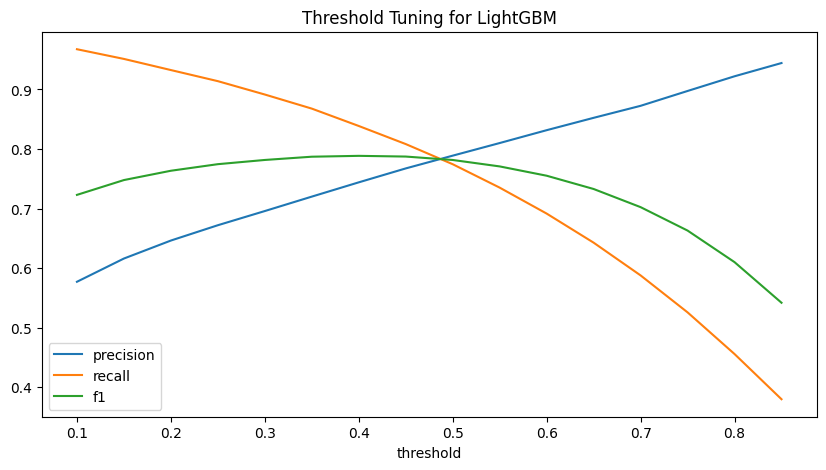

In [50]:
threshold_df.plot(x="threshold", y=["precision", "recall", "f1"], figsize=(10,5))

plt.title("Threshold Tuning for LightGBM")
plt.show()

In [ ]:
# Risk bands
def risk_band(score):
    if score < 0.2:
        return "Low"
    elif score < 0.5:
        return "Medium"
    elif score < 0.8:
        return "High"
    else:
        return "Critical"

In [52]:
# Validation output with risk bands
df_valid = X_valid.copy()
df_valid["target"] = y_valid.values
df_valid["risk_score"] = lgb_probs
df_valid["risk_band"] = df_valid["risk_score"].apply(risk_band)

df_valid[["risk_score", "risk_band"]].head()

,risk_score,risk_band
458063,0.370457,Medium
35143,0.001669,Low
190936,0.012467,Low
44579,0.641427,High
262126,0.994729,Critical


In [53]:
# Feature importance

importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": lgb_model.feature_importances_
}).sort_values("importance", ascending=False)

importance_df.head(20)

,feature,importance
31,P_2_latest,544
35,B_11_latest,472
32,D_39_latest,347
26,S_3_avg,299
61,history_days,288
34,R_1_latest,261
33,B_9_latest,252
43,P_2_delta,248
36,S_3_latest,241
8,D_39_max,224


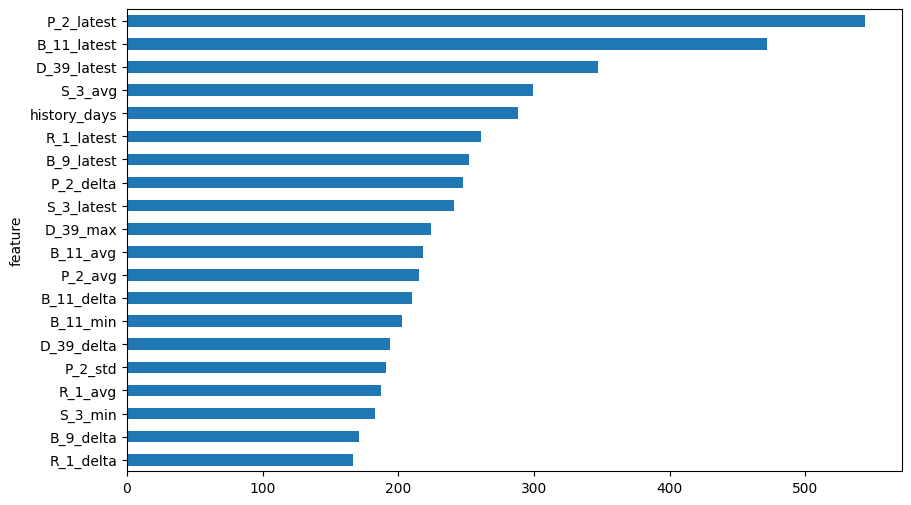

In [54]:
# Plot feature importance
importance_df.head(20).plot(
    kind="barh",
    x="feature",
    y="importance",
    figsize=(10,6),
    legend=False
)
plt.gca().invert_yaxis()